In [1]:
#Lets have matplotlib "inline"
%matplotlib inline

#Import packages we need
import numpy as np
from matplotlib import animation, rc
from matplotlib import pyplot as plt
from matplotlib import gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable
#import mpld3

import subprocess
import socket
import time
import os
import gc
import datetime
import logging

import pycuda.driver as cuda

try:
    from StringIO import StringIO
except ImportError:
    from io import StringIO

In [2]:
#Finally, import our simulator
from GPUSimulators import Common, LxF, FORCE, HLL, HLL2, KP07, KP07_dimsplit, WAF, IPythonMagic
from GPUSimulators.helpers import InitialConditions

## Logging and context

In [3]:
%setup_logging log_name
%cuda_context_handler cuda_context

Console logger using level INFO
File logger using level DEBUG to output.log
Python version 3.10.15 | packaged by conda-forge | (main, Sep 20 2024, 16:37:05) [GCC 13.3.0]
Registering cuda_context in user workspace
PyCUDA version 2024.1
CUDA version (11, 8, 0)
Driver version 12040
Using device 0/1 'Quadro GV100' (0000:01:00.0) GPU
Created context handle <108249415582624>
Using CUDA cache dir /home/aadi.bhure/Code-pk/FiniteVolumeGPU/GPUSimulators/cuda_cache
Autotuning enabled. It may take several minutes to run the code the first time: have patience


## Initial conditions

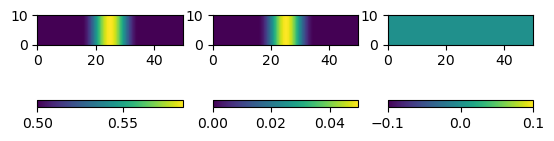

In [4]:
nx = 100
ny = 2
ref_nx = 1000
width = 50
height = width/5
bump_size = 10
h, hu, hv, dx, dy = InitialConditions.bump(nx=nx, ny=ny, width=width, height=height, bump_size=bump_size, ref_nx=ref_nx, v_amp=0, v_ref=0)

plt.figure()
ax=plt.subplot(1,3,1)
im=plt.imshow(h, extent=[0, nx*dx, 0, ny*dy])
plt.colorbar(orientation='horizontal')

ax=plt.subplot(1,3,2)
im=plt.imshow(hu, extent=[0, nx*dx, 0, ny*dy])
plt.colorbar(orientation='horizontal')

ax=plt.subplot(1,3,3)
im=plt.imshow(hv, extent=[0, nx*dx, 0, ny*dy])
plt.colorbar(orientation='horizontal')

plt.show()

In [5]:
def gen_filename(simulator, nx):
    return os.path.abspath(os.path.join("data", "smooth1d", str(simulator.__name__) + "_" + str(nx) + ".npz"))

In [6]:
def run_benchmark(datafilename, simulator, simulator_args, nx, reference_nx, ny, reference_ny,
                  h_ref=0.5, h_amp=0.1, u_ref=0.0, u_amp=0.1, v_ref=0.0, v_amp=0.1,
                  dt=None, force_rerun=False, transpose=False):
    if (datafilename and os.path.isfile(datafilename) and force_rerun == False):
        print("WARNING: Existing simulation exists, skipping simulation run")
        return [0, 0, 0]
    else:
        width = 100
        test_data_args = {
            'nx': nx,
            'ny': ny,
            'width': width,
            'height': height,
            'bump_size': width/5,
            'ref_nx': reference_nx,
            'ref_ny': reference_ny,
            'h_ref': h_ref, 'h_amp': h_amp,
            'u_ref': u_ref, 'u_amp': u_amp,
            'v_ref': v_ref, 'v_amp': v_amp
        }
        h0, hu0, hv0, dx, dy = InitialConditions.bump(**test_data_args)

        # Initialise simulator
        with Common.Timer(simulator.__name__ + "_" + str(nx)) as timer:
            if (transpose):
                h0 = np.ascontiguousarray(np.transpose(h0))
                hu0, hv0 = np.ascontiguousarray(np.transpose(hv0)), np.ascontiguousarray(np.transpose(hu0))
                dx, dy = dy, dx
                nx, ny = ny, nx

            sim_args = {
                'h0': h0, 'hu0': hu0, 'hv0': hv0,
                'nx': nx, 'ny': ny,
                'dx': dx, 'dy': dy
            }
            sim_args.update(simulator_args)

            sim = simulator(**sim_args)
            sim.simulate(1.0, dt=None)
            sim.check()

            nt = sim.simSteps()
            dt = sim.simTime() / nt
            h, hu, hv = sim.download()

            if (transpose):
                h = np.ascontiguousarray(np.transpose(h))
                hu, hv = np.ascontiguousarray(np.transpose(hv)), np.ascontiguousarray(np.transpose(hu))

            if (datafilename):
                dirname = os.path.dirname(datafilename)
                if (dirname and not os.path.isdir(dirname)):
                    os.makedirs(dirname)
                np.savez_compressed(datafilename, h=h, hu=hu, hv=hv)

    gc.collect() # Force garbage collection
    return [timer.secs, nt, dt]

In [14]:
sim_args = {
    'context': cuda_context,
    'cfl_scale': 0.9,
    'g': 9.81
}
g = 9.81
h_ref = 0.5
h_amp = 0.1
u_ref = 0.0
u_amp = 0.1
force_rerun = True
transpose = False

reference_nx = 16384
domain_sizes = [8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096]
reference_dx = width / reference_nx
dxs = width / np.array(domain_sizes)
simulators = [LxF.LxF]

sim_elapsed_time = np.zeros((len(simulators), len(domain_sizes)))
sim_dt = np.zeros_like(sim_elapsed_time)
sim_nt = np.zeros_like(sim_elapsed_time)
sim_errors = np.zeros_like(sim_elapsed_time)
sim_cons = np.zeros_like(sim_elapsed_time)

# TODO FIXME warmup!

for i in range(len(simulators)):
    # Run reference with a low CFL-number
    datafilename = gen_filename(simulators[i], reference_nx)
    _ = run_benchmark(datafilename, 
                          simulators[i],
                          sim_args,
                          reference_nx, reference_nx, 2, 2,
                          h_ref=h_ref, h_amp=h_amp,
                          u_ref=u_ref, u_amp=u_amp,
                          v_ref=0.0, v_amp=0.0,
                          #dt=0.25*0.7*(width/reference_nx)/(u_ref+u_amp + np.sqrt(g*(h_ref+h_amp))),
                          force_rerun=force_rerun,
                          transpose=transpose)
    with np.load(datafilename) as data:
        h_ref = data['h'].astype(np.float64)

    # Run on sizes
    for j, nx in enumerate(domain_sizes):
        datafilename = gen_filename(simulators[i], nx)
        secs, nt, dt = run_benchmark(datafilename, 
                          simulators[i],
                          sim_args,
                          nx, reference_nx, 2, 2,
                          h_ref=h_ref, h_amp=h_amp,
                          u_ref=u_ref, u_amp=u_amp,
                          v_ref=0.0, v_amp=0.0,
                          #dt=0.25*0.7*(width/reference_nx)/(u_ref+u_amp + np.sqrt(g*(h_ref+h_amp))),
                          force_rerun=force_rerun,
                          transpose=transpose)
        
        with np.load(datafilename) as data:
            h = data['h'].astype(np.float64)
        # downsample
        h_ref_downsampled = InitialConditions.downsample(h_ref, reference_nx / nx, 1)

        # error
        dx = dxs[j]
        error = np.linalg.norm((h_ref_downsampled - h).flatten(), ord = 1) * dx
        conservation = (np.sum(h_ref) * reference_dx - np.sum(h) * dx)

        # store
        sim_elapsed_time[i, j] = secs
        sim_nt[i, j] = nt
        sim_dt[i, j] = dt
        sim_errors[i, j] = error
        sim_cons[i, j] = conservation
        print(j)

gc.collect()

Exception caught: Resetting to CUDA context cuda_context
Traceback (most recent call last):
  File "/home/aadi.bhure/miniforge3/envs/ShallowWaterGPU_py310/lib/python3.10/site-packages/IPython/core/interactiveshell.py", line 3577, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_555854/519170644.py", line 47, in <module>
    secs, nt, dt = run_benchmark(datafilename,
  File "/tmp/ipykernel_555854/2040676313.py", line 38, in run_benchmark
    sim = simulator(**sim_args)
  File "/home/aadi.bhure/Code-pk/FiniteVolumeGPU/GPUSimulators/LxF.py", line 89, in __init__
    self.u0 = Common.ArakawaA2D(self.stream,
  File "/home/aadi.bhure/Code-pk/FiniteVolumeGPU/GPUSimulators/Common.py", line 749, in __init__
    self.gpu_variables += [CudaArray2D(stream, nx, ny, halo_x, halo_y, cpu_variable)]
  File "/home/aadi.bhure/Code-pk/FiniteVolumeGPU/GPUSimulators/Common.py", line 525, in __init__
    assert cpu_data.itemsize == 4, "Wrong size of data type"
Assertio

AssertionError: Wrong size of data type